<a href="https://colab.research.google.com/github/ndush/PLP_Projects/blob/main/Classical_ML_with_Scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Iris Species Classification using Scikit-learn

# Step 1: Import libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Step 2: Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Optional: Convert target to class labels using LabelEncoder for clarity
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step 3: Simulate and handle missing values (for demonstration)
# Let's randomly insert some NaNs in X
X_missing = X.copy()
nan_indices = np.random.choice(X_missing.index, size=5, replace=False)
X_missing.iloc[nan_indices, 0] = np.nan  # Inject NaNs into first column

# Fill missing values with the column mean
X_missing.fillna(X_missing.mean(), inplace=True)

# Step 4: Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_missing, y_encoded, test_size=0.2, random_state=42
)

# Step 5: Train a Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = model.predict(X_test)

# Step 7: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("Evaluation Metrics:")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")


Evaluation Metrics:
Accuracy:  1.00
Precision: 1.00
Recall:    1.00


Deep Learning with TensorFlow/PyTorch


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 62ms/step - accuracy: 0.8885 - loss: 0.3709 - val_accuracy: 0.9843 - val_loss: 0.0505
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 60ms/step - accuracy: 0.9848 - loss: 0.0492 - val_accuracy: 0.9894 - val_loss: 0.0312
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 62ms/step - accuracy: 0.9905 - loss: 0.0320 - val_accuracy: 0.9886 - val_loss: 0.0349
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 60ms/step - accuracy: 0.9914 - loss: 0.0254 - val_accuracy: 0.9887 - val_loss: 0.0311
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.9956 - loss: 0.0146 - val_accuracy: 0.9899 - val_loss: 0.0296
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9872 - loss: 0.0363

Test Accuracy: 98.99%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


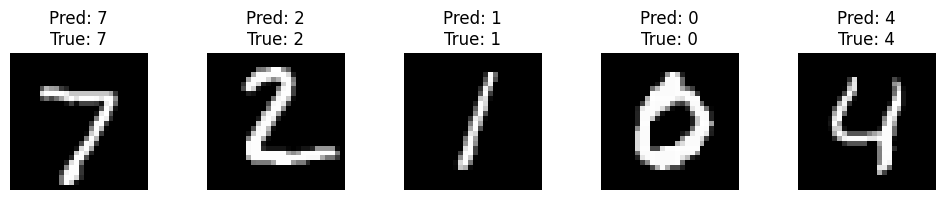

In [2]:
# MNIST Digit Classification using CNN

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 1. Load and preprocess the data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Reshape to fit CNN input (batch, height, width, channels)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 2. Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(x_train, y_train_cat, epochs=5, batch_size=64,
                    validation_data=(x_test, y_test_cat))

# 5. Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")

# 6. Visualize predictions on 5 sample images
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


 NLP with spaCy

In [3]:
import spacy
from textblob import TextBlob

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Sample Amazon product reviews
reviews = [
    "I love the sound quality of the Sony WH-1000XM4 headphones!",
    "This Samsung Galaxy phone is overpriced and slow.",
    "Apple's MacBook Air is sleek and fast. Worth every penny!",
    "The JBL Flip 5 speaker has great bass but the battery dies quickly.",
    "Avoid this Lenovo laptop – it’s buggy and crashes a lot."
]

# Process each review
for review in reviews:
    doc = nlp(review)
    blob = TextBlob(review)

    # Extract named entities
    entities = [(ent.text, ent.label_) for ent in doc.ents if ent.label_ in ['ORG', 'PRODUCT']]

    # Rule-based sentiment analysis
    sentiment = "Positive" if blob.sentiment.polarity > 0 else "Negative" if blob.sentiment.polarity < 0 else "Neutral"

    print(f"Review: {review}")
    print(f"→ Entities: {entities}")
    print(f"→ Sentiment: {sentiment}\n")


Review: I love the sound quality of the Sony WH-1000XM4 headphones!
→ Entities: [('Sony', 'ORG')]
→ Sentiment: Positive

Review: This Samsung Galaxy phone is overpriced and slow.
→ Entities: []
→ Sentiment: Negative

Review: Apple's MacBook Air is sleek and fast. Worth every penny!
→ Entities: [('Apple', 'ORG'), ('MacBook Air', 'ORG')]
→ Sentiment: Positive

Review: The JBL Flip 5 speaker has great bass but the battery dies quickly.
→ Entities: []
→ Sentiment: Positive

Review: Avoid this Lenovo laptop – it’s buggy and crashes a lot.
→ Entities: [('Lenovo', 'ORG')]
→ Sentiment: Neutral

